# Section 3 — Pandas on a Real Dataset (Wine)
**Course:** Data Mining
**Project:** FitZone Sports
**Reference:** `Section+3_+Data+Mining.pdf`, `Section+3_Data+Mining_notebook.html`,
`missing_values.html`

> Eng. Taher's task: *apply **every** function from the section notebook to a
> Kaggle / public dataset.*

We use the **Wine** dataset (built into scikit-learn — no Kaggle download
required). It has 178 rows, 13 numeric features, and a 3-class label
(`wine_class` ∈ {class_0, class_1, class_2}).

To swap in your own Kaggle CSV, just change the `pd.read_csv(...)` call in
cell 2.

## 1. Load the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

# Load Wine and turn it into a DataFrame (no Kaggle download required)
wine = load_wine(as_frame=True)
data = wine.frame.rename(columns={"target": "wine_class_code"})
class_map = {0: "class_0", 1: "class_1", 2: "class_2"}
data["wine_class"] = data["wine_class_code"].map(class_map)
data = data.drop(columns=["wine_class_code"])

# Save & reload — proves the read_csv pipeline works end-to-end
data.to_csv("wine.csv", index=False)
x = pd.read_csv("wine.csv")
print("shape :", x.shape)
x.head()

shape : (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


## 2. Inspecting the data (`shape`, `dtypes`, `info`, `describe`, `columns`)

In [2]:
x.shape

(178, 14)

In [3]:
x.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
wine_class                          str
dtype: object

In [4]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  wine_class      

In [5]:
x.describe()                        # numeric summary

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [6]:
x.describe(include=['O'])           # object (string) summary — 'wine_class' here

/tmp/ipykernel_11460/2546918360.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  x.describe(include=['O'])           # object (string) summary — 'wine_class' here


,wine_class
count,178
unique,3
top,class_1
freq,71


In [7]:
x['alcohol'].describe()             # one-column summary

count    178.000000
mean      13.000618
std        0.811827
min       11.030000
25%       12.362500
50%       13.050000
75%       13.677500
max       14.830000
Name: alcohol, dtype: float64

In [8]:
x.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'wine_class'],
      dtype='str')

In [9]:
x.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


In [10]:
x.tail()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.7,0.64,1.74,740.0,class_2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.3,0.70,1.56,750.0,class_2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.2,0.59,1.56,835.0,class_2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.3,0.60,1.62,840.0,class_2
177,14.13,4.10,2.74,24.5,96.0,2.05,0.76,0.56,1.35,9.2,0.61,1.60,560.0,class_2


In [11]:
x.sample(n=5, random_state=1)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
161,13.69,3.26,2.54,20.0,107.0,1.83,0.56,0.50,0.80,5.88,0.96,1.82,680.0,class_2
117,12.42,1.61,2.19,22.5,108.0,2.00,2.09,0.34,1.61,2.06,1.06,2.96,345.0,class_1
19,13.64,3.10,2.56,15.2,116.0,2.70,3.03,0.17,1.66,5.10,0.96,3.36,845.0,class_0
69,12.21,1.19,1.75,16.8,151.0,1.85,1.28,0.14,2.50,2.85,1.28,3.07,718.0,class_1
53,13.77,1.90,2.68,17.1,115.0,3.00,2.79,0.39,1.68,6.30,1.13,2.93,1375.0,class_0


In [12]:
x.sample(frac=0.05, random_state=1)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
161,13.69,3.26,2.54,20.0,107.0,1.83,0.56,0.50,0.80,5.88,0.96,1.82,680.0,class_2
117,12.42,1.61,2.19,22.5,108.0,2.00,2.09,0.34,1.61,2.06,1.06,2.96,345.0,class_1
19,13.64,3.10,2.56,15.2,116.0,2.70,3.03,0.17,1.66,5.10,0.96,3.36,845.0,class_0
69,12.21,1.19,1.75,16.8,151.0,1.85,1.28,0.14,2.50,2.85,1.28,3.07,718.0,class_1
53,13.77,1.90,2.68,17.1,115.0,3.00,2.79,0.39,1.68,6.30,1.13,2.93,1375.0,class_0
138,13.49,3.59,2.19,19.5,88.0,1.62,0.48,0.58,0.88,5.70,0.81,1.82,580.0,class_2
112,11.76,2.68,2.92,20.0,103.0,1.75,2.03,0.60,1.05,3.80,1.23,2.50,607.0,class_1
14,14.38,1.87,2.38,12.0,102.0,3.30,3.64,0.29,2.96,7.50,1.20,3.00,1547.0,class_0
160,12.36,3.83,2.38,21.0,88.0,2.30,0.92,0.50,1.04,7.65,0.56,1.58,520.0,class_2


## 3. Selection — `.loc` and `.iloc`

In [13]:
x.loc[1]                       # row index 1

alcohol                            13.2
malic_acid                         1.78
ash                                2.14
alcalinity_of_ash                  11.2
magnesium                         100.0
total_phenols                      2.65
flavanoids                         2.76
nonflavanoid_phenols               0.26
proanthocyanins                    1.28
color_intensity                    4.38
hue                                1.05
od280/od315_of_diluted_wines        3.4
proline                          1050.0
wine_class                      class_0
Name: 1, dtype: object

In [14]:
x.loc[:, 'wine_class']         # 'wine_class' column for all rows

0      class_0
1      class_0
2      class_0
3      class_0
4      class_0
        ...   
173    class_2
174    class_2
175    class_2
176    class_2
177    class_2
Name: wine_class, Length: 178, dtype: str

In [15]:
x.iloc[:, -1]                  # last column (= wine_class)

0      class_0
1      class_0
2      class_0
3      class_0
4      class_0
        ...   
173    class_2
174    class_2
175    class_2
176    class_2
177    class_2
Name: wine_class, Length: 178, dtype: str

In [16]:
x.iloc[0:5, 0:3]               # first 5 rows, first 3 columns

,alcohol,malic_acid,ash
0,14.23,1.71,2.43
1,13.20,1.78,2.14
2,13.16,2.36,2.67
3,14.37,1.95,2.50
4,13.24,2.59,2.87


## 4. Drop rows / columns

In [17]:
xx = x.drop([1, 4], axis=0)    # drop rows with index 1 and 4
xx.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,class_0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,class_0


In [18]:
yy = x.drop(['ash', 'magnesium'], axis=1)   # drop columns
yy.head()

,alcohol,malic_acid,alcalinity_of_ash,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,15.6,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,11.2,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,18.6,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,16.8,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,21.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


## 5. Filter, sort, rename

In [19]:
z = x.query('wine_class == "class_1"')
z.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
59,12.37,0.94,1.36,10.6,88.0,1.98,0.57,0.28,0.42,1.95,1.05,1.82,520.0,class_1
60,12.33,1.10,2.28,16.0,101.0,2.05,1.09,0.63,0.41,3.27,1.25,1.67,680.0,class_1
61,12.64,1.36,2.02,16.8,100.0,2.02,1.41,0.53,0.62,5.75,0.98,1.59,450.0,class_1
62,13.67,1.25,1.92,18.0,94.0,2.10,1.79,0.32,0.73,3.80,1.23,2.46,630.0,class_1
63,12.37,1.13,2.16,19.0,87.0,3.50,3.10,0.19,1.87,4.45,1.22,2.87,420.0,class_1


In [20]:
zz = x.sort_values(by='alcohol', ascending=True)
zz.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
115,11.03,1.51,2.20,21.5,85.0,2.46,2.17,0.52,2.01,1.90,1.71,2.87,407.0,class_1
113,11.41,0.74,2.50,21.0,88.0,2.48,2.01,0.42,1.44,3.08,1.10,2.31,434.0,class_1
120,11.45,2.40,2.42,20.0,96.0,2.90,2.79,0.32,1.83,3.25,0.80,3.39,625.0,class_1
110,11.46,3.74,1.82,19.5,107.0,3.18,2.58,0.24,3.58,2.90,0.75,2.81,562.0,class_1
121,11.56,2.05,3.23,28.5,119.0,3.18,5.08,0.47,1.87,6.00,0.93,3.69,465.0,class_1


In [21]:
x.rename(columns={'alcohol': 'alc_pct'}).head()

,alc_pct,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


## 6. Categorical column

In [22]:
x['wine_class'].astype('category')

0      class_0
1      class_0
2      class_0
3      class_0
4      class_0
        ...   
173    class_2
174    class_2
175    class_2
176    class_2
177    class_2
Name: wine_class, Length: 178, dtype: category
Categories (3, str): ['class_0', 'class_1', 'class_2']

## 7. Plots — histogram & boxplot

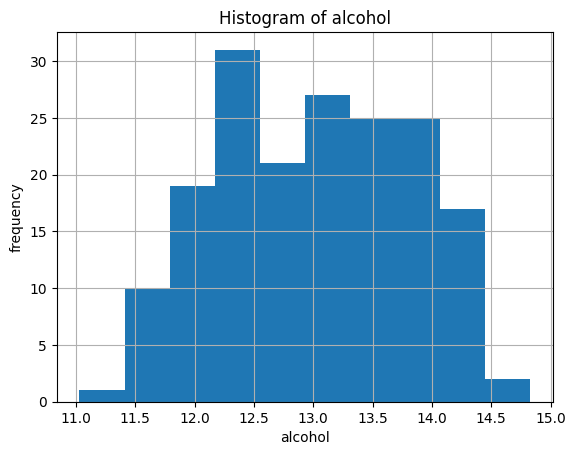

In [23]:
x['alcohol'].hist()
plt.title('Histogram of alcohol')
plt.xlabel('alcohol')
plt.ylabel('frequency')
plt.show()

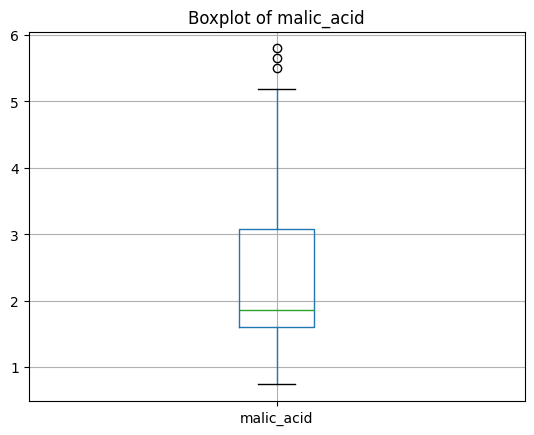

In [24]:
x.boxplot(column='malic_acid')
plt.title('Boxplot of malic_acid')
plt.show()

## 8. Missing-values handling

We deliberately punch some `NaN` values into a copy of the dataset to demonstrate
all the strategies from `missing_values.html`.

In [25]:
rng = np.random.default_rng(0)
m = x.copy().astype({'wine_class': 'object'})

# inject ~10% NaNs in numeric columns
mask = rng.random(size=m.shape) < 0.10
mask[:, m.columns.get_loc('wine_class')] = False  # don't break the label column
m = m.where(~mask)

print("NaNs per column:")
print(m.isnull().sum())
print("Total NaNs :", m.isnull().sum().sum())
m.head(8)

NaNs per column:
alcohol                         23
malic_acid                      15
ash                             20
alcalinity_of_ash               22
magnesium                       21
total_phenols                   17
flavanoids                      20
nonflavanoid_phenols            17
proanthocyanins                 14
color_intensity                 19
hue                             24
od280/od315_of_diluted_wines    22
proline                         17
wine_class                       0
dtype: int64
Total NaNs : 251


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,NaN,NaN,127.0,2.80,3.06,0.28,2.29,5.64,1.04,NaN,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,NaN,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,NaN,0.24,2.18,7.80,0.86,NaN,1480.0,class_0
4,13.24,2.59,2.87,NaN,118.0,2.80,NaN,0.39,1.82,4.32,1.04,2.93,735.0,class_0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,class_0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,NaN,5.25,1.02,3.58,1290.0,class_0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,NaN,3.58,1295.0,class_0


### 8.1 Drop strategies

In [26]:
m.dropna(how='any').head()           # drop rows with ANY NaN

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,class_0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0,class_0
12,13.75,1.73,2.41,16.0,89.0,2.60,2.76,0.29,1.81,5.60,1.15,2.90,1320.0,class_0
22,13.71,1.86,2.36,16.6,101.0,2.61,2.88,0.27,1.69,3.80,1.11,4.00,1035.0,class_0


In [27]:
m.dropna(how='all').head()           # drop rows where ALL values are NaN

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,NaN,NaN,127.0,2.80,3.06,0.28,2.29,5.64,1.04,NaN,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,NaN,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,NaN,0.24,2.18,7.80,0.86,NaN,1480.0,class_0
4,13.24,2.59,2.87,NaN,118.0,2.80,NaN,0.39,1.82,4.32,1.04,2.93,735.0,class_0


### 8.2 Fill with constant

In [28]:
m.fillna(0).head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,0.00,0.0,127.0,2.80,3.06,0.28,2.29,5.64,1.04,0.00,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,0.00,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,0.00,0.24,2.18,7.80,0.86,0.00,1480.0,class_0
4,13.24,2.59,2.87,0.0,118.0,2.80,0.00,0.39,1.82,4.32,1.04,2.93,735.0,class_0


In [29]:
m.fillna({'alcohol': 0, 'malic_acid': 0, 'ash': 0, 'magnesium': 0}).head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,0.00,NaN,127.0,2.80,3.06,0.28,2.29,5.64,1.04,NaN,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,NaN,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,NaN,0.24,2.18,7.80,0.86,NaN,1480.0,class_0
4,13.24,2.59,2.87,NaN,118.0,2.80,NaN,0.39,1.82,4.32,1.04,2.93,735.0,class_0


### 8.3 Forward / backward fill
The lecture slides show `m.fillna(method='ffill')`. In recent pandas releases
the `method=` argument is replaced by the dedicated `.ffill()` / `.bfill()`
methods (same behaviour). Both styles are shown below.

In [30]:
# Modern API (pandas >= 2.1)
m.ffill().head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,NaN,NaN,127.0,2.80,3.06,0.28,2.29,5.64,1.04,NaN,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,3.06,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.24,0.24,2.18,7.80,0.86,3.17,1480.0,class_0
4,13.24,2.59,2.87,16.8,118.0,2.80,3.24,0.39,1.82,4.32,1.04,2.93,735.0,class_0


In [31]:
# Modern API (pandas >= 2.1)
m.bfill().head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.14,11.2,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.40,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,3.24,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.39,0.24,2.18,7.80,0.86,2.93,1480.0,class_0
4,13.24,2.59,2.87,15.2,118.0,2.80,3.39,0.39,1.82,4.32,1.04,2.93,735.0,class_0


In [32]:
# Legacy syntax from the lecture slides — still works on older pandas
try:
    m.fillna(method='ffill').head()
except TypeError:
    print("This pandas version requires .ffill() instead of "
          "fillna(method='ffill') — use the cell above.")

This pandas version requires .ffill() instead of fillna(method='ffill') — use the cell above.


### 8.4 Statistical imputation (mean / median / mode)

In [33]:
m.fillna(m.mean(numeric_only=True)).head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.359937,19.470513,127.0,2.80,3.060000,0.28,2.29,5.64,1.04,2.593013,1065.0,class_0
1,13.20,1.78,2.140000,11.200000,100.0,2.65,2.019873,0.26,1.28,4.38,1.05,3.400000,1050.0,class_0
2,13.16,2.36,2.670000,18.600000,101.0,2.80,3.240000,0.30,2.81,5.68,1.03,3.170000,1185.0,class_0
3,14.37,1.95,2.500000,16.800000,113.0,3.85,2.019873,0.24,2.18,7.80,0.86,2.593013,1480.0,class_0
4,13.24,2.59,2.870000,19.470513,118.0,2.80,2.019873,0.39,1.82,4.32,1.04,2.930000,735.0,class_0


In [34]:
m.fillna(m.median(numeric_only=True)).head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.36,19.45,127.0,2.80,3.060,0.28,2.29,5.64,1.04,2.78,1065.0,class_0
1,13.20,1.78,2.14,11.20,100.0,2.65,2.065,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.60,101.0,2.80,3.240,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.80,113.0,3.85,2.065,0.24,2.18,7.80,0.86,2.78,1480.0,class_0
4,13.24,2.59,2.87,19.45,118.0,2.80,2.065,0.39,1.82,4.32,1.04,2.93,735.0,class_0


In [35]:
m.fillna(m.mode().iloc[0]).head()    # mode (per column)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.28,20.0,127.0,2.80,3.06,0.28,2.29,5.64,1.04,1.82,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.65,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,2.65,0.24,2.18,7.80,0.86,1.82,1480.0,class_0
4,13.24,2.59,2.87,20.0,118.0,2.80,2.65,0.39,1.82,4.32,1.04,2.93,735.0,class_0


## 9. Save the cleaned data

In [36]:
cleaned = m.fillna(m.mean(numeric_only=True))
cleaned.to_csv("wine_cleaned.csv", index=False)
print("rows after clean:", cleaned.shape[0])
cleaned.head()

rows after clean: 178


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.359937,19.470513,127.0,2.80,3.060000,0.28,2.29,5.64,1.04,2.593013,1065.0,class_0
1,13.20,1.78,2.140000,11.200000,100.0,2.65,2.019873,0.26,1.28,4.38,1.05,3.400000,1050.0,class_0
2,13.16,2.36,2.670000,18.600000,101.0,2.80,3.240000,0.30,2.81,5.68,1.03,3.170000,1185.0,class_0
3,14.37,1.95,2.500000,16.800000,113.0,3.85,2.019873,0.24,2.18,7.80,0.86,2.593013,1480.0,class_0
4,13.24,2.59,2.870000,19.470513,118.0,2.80,2.019873,0.39,1.82,4.32,1.04,2.930000,735.0,class_0


---
**End of Section 3 notebook.** All Pandas + missing-value functions from the
lecture have been demonstrated on the Wine dataset.